In [ ]:
from builders.simple_generator import generate_batch
from src.builders.image_builder import ImageGenerator
from src.utils.classes.config import GenerationConfig
from src.visualization.visualize_output import show_images

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import keras
import numpy as np
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv

# Eksperyment pierwszy
Eksperyment, w którym definiujemy dwa zbiory z różnicami w wielkości komórek. Utworzone zostaną dwa zbiory z różnicą w rozmiarze komórek w zbiorze testowym. Ma to na celu sprawdzenie czy istnieje
różnica w MSE.

Konfiguracja zbiorów

In [ ]:
larger_cells_images_conf = GenerationConfig()
larger_cells_images_conf.axes.mean_x = 22
larger_cells_images_conf.axes.mean_y = 16
larger_cells_images_conf.axes.std_x = 6
larger_cells_images_conf.distribution.radius = 40

larger_cells = ImageGenerator(larger_cells_images_conf)

Utworzenie zbioru i sprawdzenie wyników

Generated 9 centers
Generated 8 centers
Generated 8 centers
Generated 8 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 8 centers
Generated 9 centers
Generated 11 centers
Generated 11 centers
Generated 8 centers
Generated 8 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 9 centers
Generated 8 centers
Generated 8 centers
Generated 8 centers
Generated 11 centers
Generated 8 centers
Generated 9 centers
Generated 9 centers
Generated 10 centers
Generated 9 centers
Generated 9 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 7 centers
Generated 9 centers
Generated 9 centers
Generated 11 centers
Generated 9 centers
Generated 9 centers
Generated 10 centers
Generated 9 centers
Generated 8 centers
Generated 11 centers
Generated 8 centers
Generated 12 centers
Generated 10 centers
Generated 10 centers
Genera

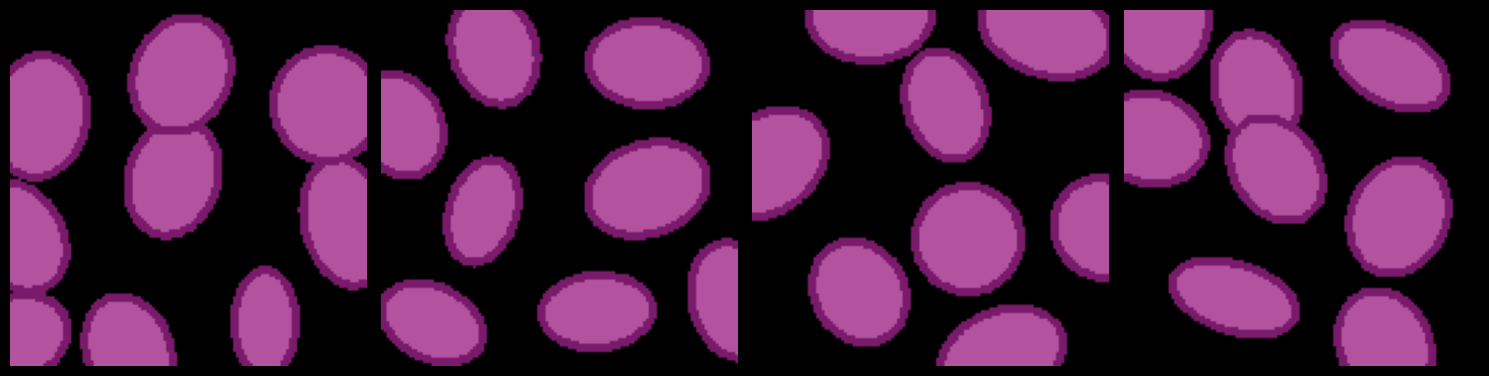

In [31]:
larger_cells_set = larger_cells.build_batch(2000)

show_images(larger_cells_set[:4])

# Eksperyment drugi
Eksperyment ma na celu sprawdzenie błędu MSE w sytuacji gdy zmienia się kolor komórek.

Konfiguracja komórki

In [32]:
different_colors_conf = GenerationConfig()
different_colors_conf.nucleus.base_color = (134, 80, 34)
different_colors_conf.nucleus.border_color = (29, 40, 182)

different_colors_cells = ImageGenerator(different_colors_conf)

Utworzenie zbioru i sprawdzenie wyników

Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 17 centers
Generated 15 centers
Generated 14 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 17 centers
Generated 14 centers
Generated 16 centers
Generated 17 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 13 centers
Generated 13 centers
Generated 15 centers
Generated 12 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 18 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 14 

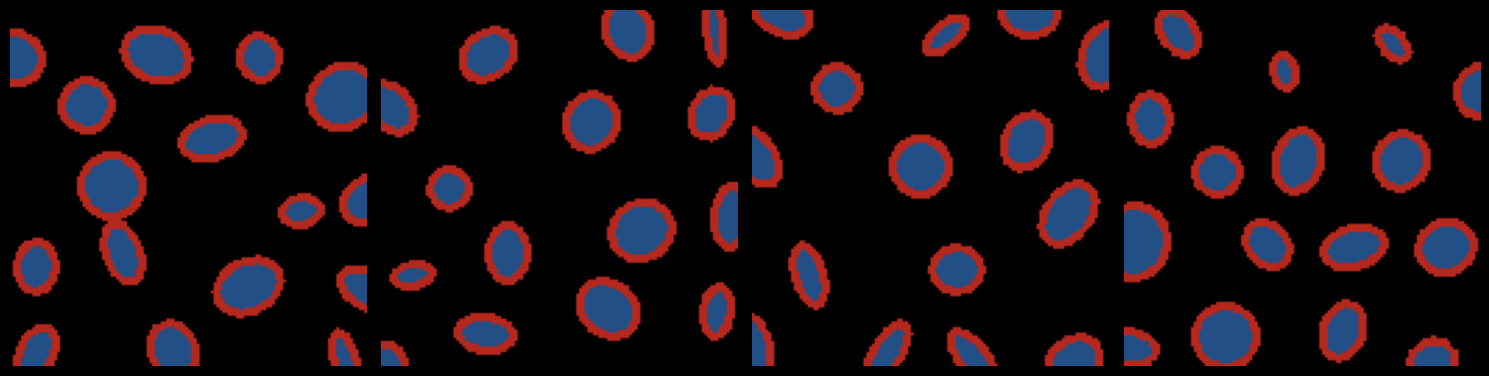

In [33]:
different_color_cells_set = different_colors_cells.build_batch(2000)

show_images(different_color_cells_set[:4])

# Eksperyment trzeci
W eksperymencie sprawdzone zostanie wpływ rozkładu komórek na błąd MSE.

Konfiguracja komórki

In [34]:
distribution_conf = GenerationConfig()
distribution_conf.distribution.algorithm = "gaussian"

gaussian_dist_cells = ImageGenerator(distribution_conf)

Utworzenie zbioru i sprawdzenie wyników

Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 centers
Generated 10 

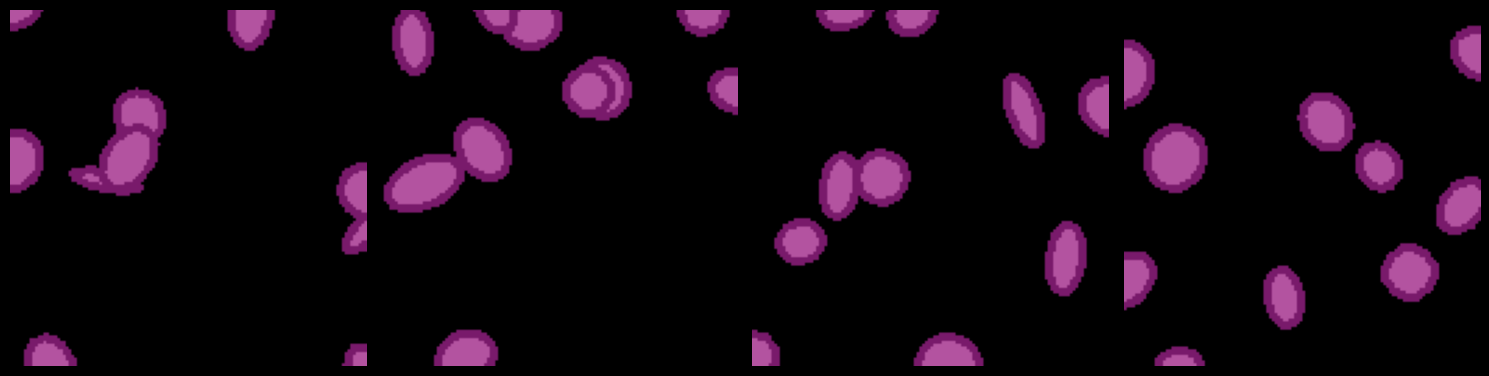

In [35]:
gaussian_dist_set = gaussian_dist_cells.build_batch(2000)

show_images(gaussian_dist_set[:4])

# Eksperyment czwarty
Sprawdzenie wpływu zniekształcenia kształtu komórek za pomocą szumu perlina na wynik MSE.

In [38]:
perlin_noise_conf = (ImageGenerator()
                     .with_perlin_noise(True))

Utworzenie zbioru i sprawdzenie wyników.

Generated 13 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 12 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 15 centers
Generated 13 centers
Generated 13 centers
Generated 13 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 18 centers
Generated 16 centers
Generated 15 centers
Generated 17 centers
Generated 14 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 17 centers
Generated 13 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 16 

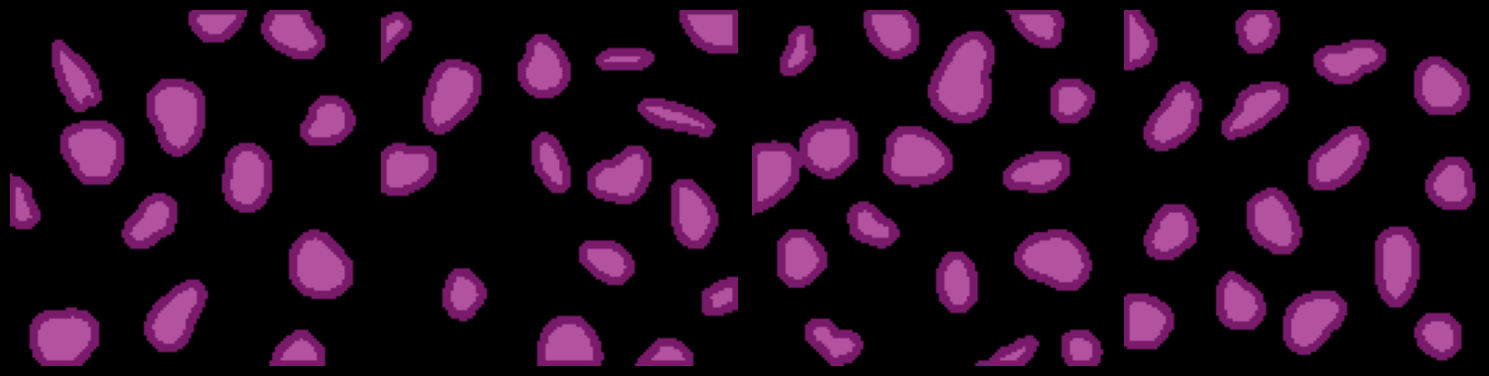

In [39]:
perlin_noise_set = perlin_noise_conf.build_batch(2000)

show_images(perlin_noise_set[:4])

# Eksperyment piąty

Połączenie wszystkich dotychczasowych eksperymentów.


In [40]:
various_conf = (ImageGenerator()
                .with_axes_config(16,18)
                .with_perlin_noise(True)
                .with_clustered_distribution(deviation=1)
                .with_cancer_cells(color=(23,190,40),
                                   border_color=(80,23,22)))

Utworzenie zbioru i sprawdzenie wyników.

Generated 7 centers
Generated 3 centers
Generated 5 centers
Generated 6 centers
Generated 4 centers
Generated 6 centers
Generated 3 centers
Generated 4 centers
Generated 5 centers
Generated 8 centers
Generated 7 centers
Generated 5 centers
Generated 7 centers
Generated 7 centers
Generated 5 centers
Generated 4 centers
Generated 2 centers
Generated 4 centers
Generated 8 centers
Generated 4 centers
Generated 3 centers
Generated 6 centers
Generated 8 centers
Generated 4 centers
Generated 4 centers
Generated 5 centers
Generated 3 centers
Generated 5 centers
Generated 6 centers
Generated 6 centers
Generated 4 centers
Generated 3 centers
Generated 5 centers
Generated 7 centers
Generated 5 centers
Generated 6 centers
Generated 8 centers
Generated 6 centers
Generated 3 centers
Generated 6 centers
Generated 8 centers
Generated 4 centers
Generated 6 centers
Generated 3 centers
Generated 6 centers
Generated 6 centers
Generated 5 centers
Generated 4 centers
Generated 4 centers
Generated 7 centers


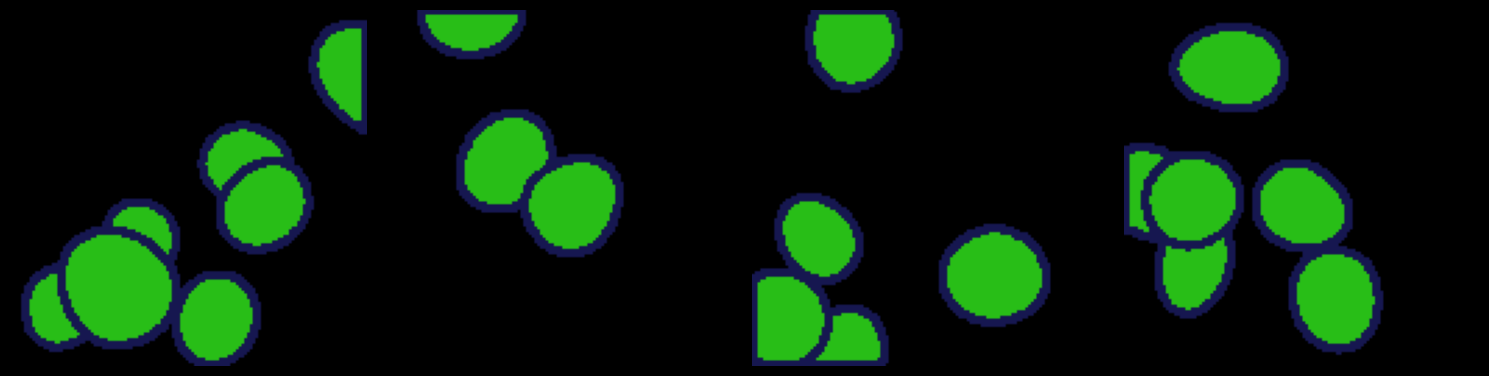

In [41]:
various_conf_set = various_conf.build_batch(2000)
show_images(various_conf_set[:4])

# Enkoder

Przygorowanie zbioru treningowego, walidacyjnego oraz testowego

Generated 13 centers
Generated 14 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 17 centers
Generated 17 centers
Generated 17 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 14 centers
Generated 17 centers
Generated 13 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 14 centers
Generated 16 centers
Generated 17 centers
Generated 14 centers
Generated 16 centers
Generated 15 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 16 centers
Generated 18 centers
Generated 14 centers
Generated 17 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 15 

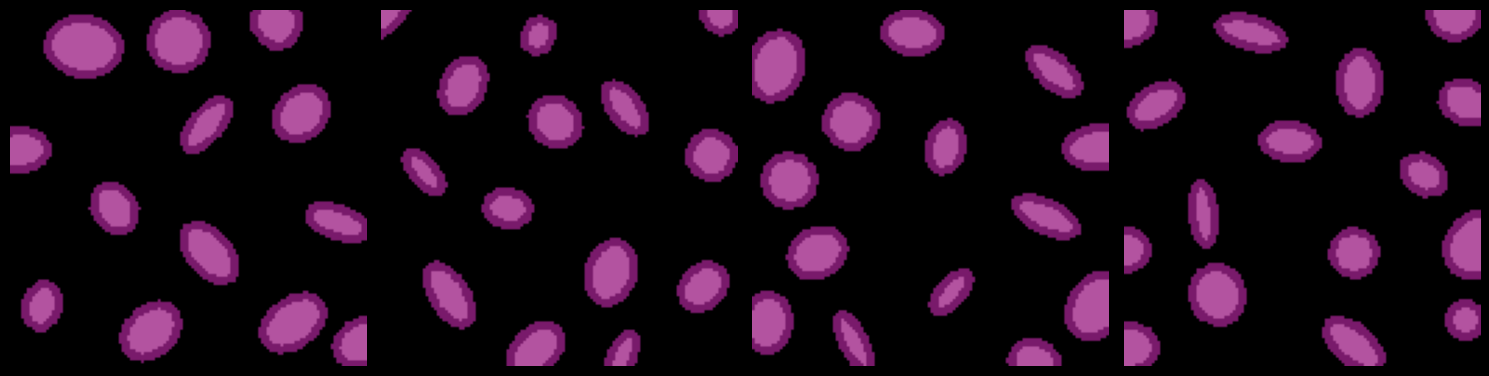

In [44]:
training_set = generate_batch(5000)

show_images(training_set[:4])

Generated 15 centers
Generated 15 centers
Generated 17 centers
Generated 14 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 13 centers
Generated 15 centers
Generated 17 centers
Generated 16 centers
Generated 16 centers
Generated 14 centers
Generated 15 centers
Generated 13 centers
Generated 17 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 13 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 15 centers
Generated 13 centers
Generated 16 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 14 centers
Generated 14 centers
Generated 17 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 17 centers
Generated 14 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 14 

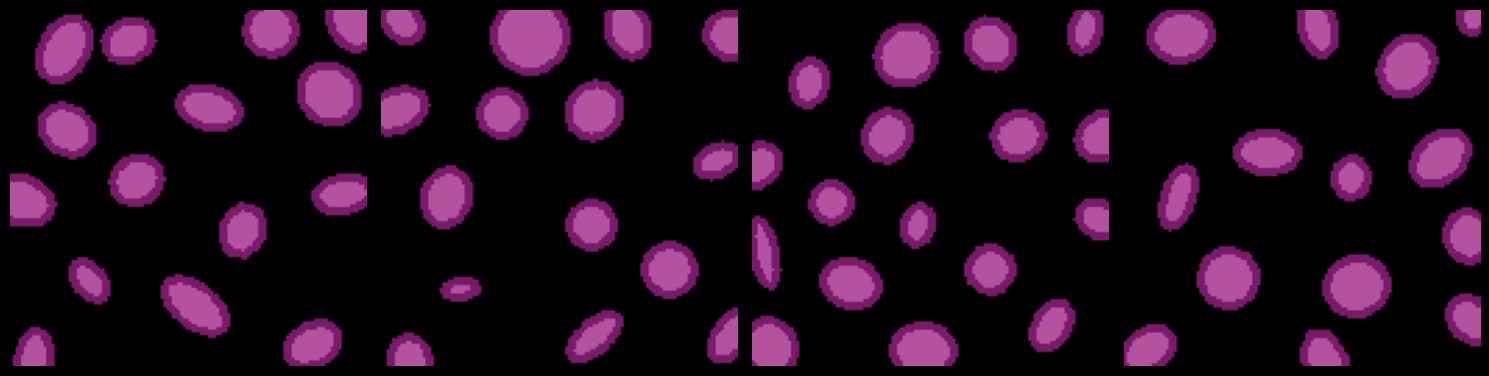

In [45]:
validation_set = generate_batch(1000)

show_images(validation_set[:4])

Generated 15 centers
Generated 15 centers
Generated 18 centers
Generated 14 centers
Generated 13 centers
Generated 16 centers
Generated 16 centers
Generated 16 centers
Generated 13 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 17 centers
Generated 14 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 17 centers
Generated 15 centers
Generated 13 centers
Generated 17 centers
Generated 15 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 14 centers
Generated 15 centers
Generated 14 centers
Generated 16 centers
Generated 14 centers
Generated 16 centers
Generated 14 centers
Generated 14 centers
Generated 13 centers
Generated 15 centers
Generated 16 centers
Generated 16 centers
Generated 15 centers
Generated 15 centers
Generated 16 centers
Generated 15 centers
Generated 16 centers
Generated 13 

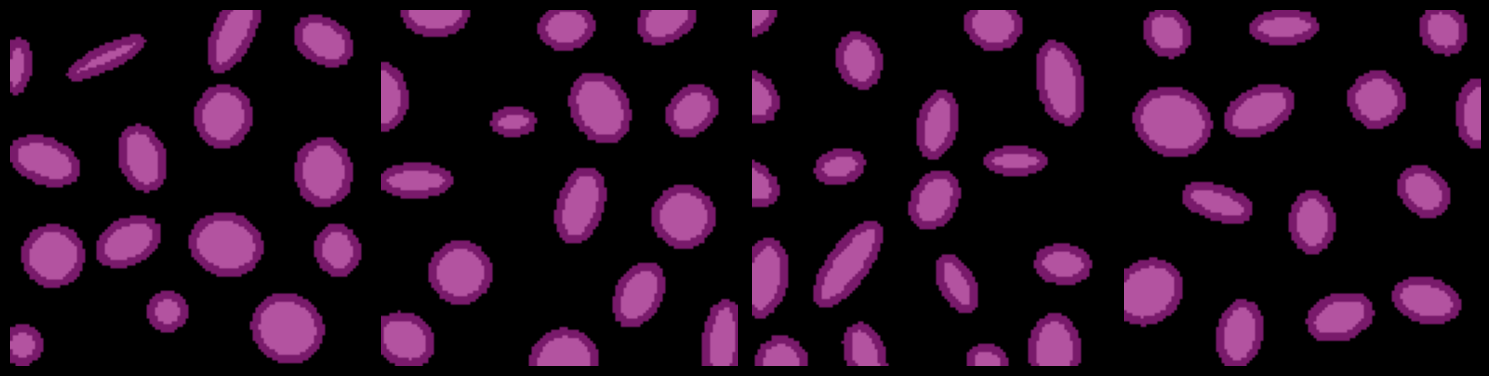

In [46]:
test_set = generate_batch(2000)

show_images(test_set[:4])

Przygotowanie danych dla enkodera

In [47]:
def preprocess(data_list):
    return np.array(data_list, dtype='float32') / 255.

In [48]:
x_test_data = preprocess(test_set)
x_val_data = preprocess(validation_set)
x_traning_data = preprocess(training_set)

Inplementacja enkodera

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 112ms/step - accuracy: 0.3160 - loss: 0.1893 - mse: 0.0114 - val_accuracy: 0.2651 - val_loss: 0.1570 - val_mse: 0.0023
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.2556 - loss: 0.1552 - mse: 0.0020 - val_accuracy: 0.2489 - val_loss: 0.1539 - val_mse: 0.0017
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.3391 - loss: 0.1531 - mse: 0.0014 - val_accuracy: 0.4543 - val_loss: 0.1525 - val_mse: 0.0012
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - accuracy: 0.5161 - loss: 0.1522 - mse: 0.0012 - val_accuracy: 0.5654 - val_loss: 0.1518 - val_mse: 0.0011
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.5885 - loss: 0.1519 - mse: 0.0011 - val_accuracy: 0.6246 - val_loss: 0.1515 - val_mse: 9.4571e-04
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - accuracy: 0.6476 - loss: 0.1514 - mse: 9.4801e-04 - val_accuracy: 0.6724 - val_loss: 0.1513 - val_mse: 8.7394e-04
Epoch 7/50

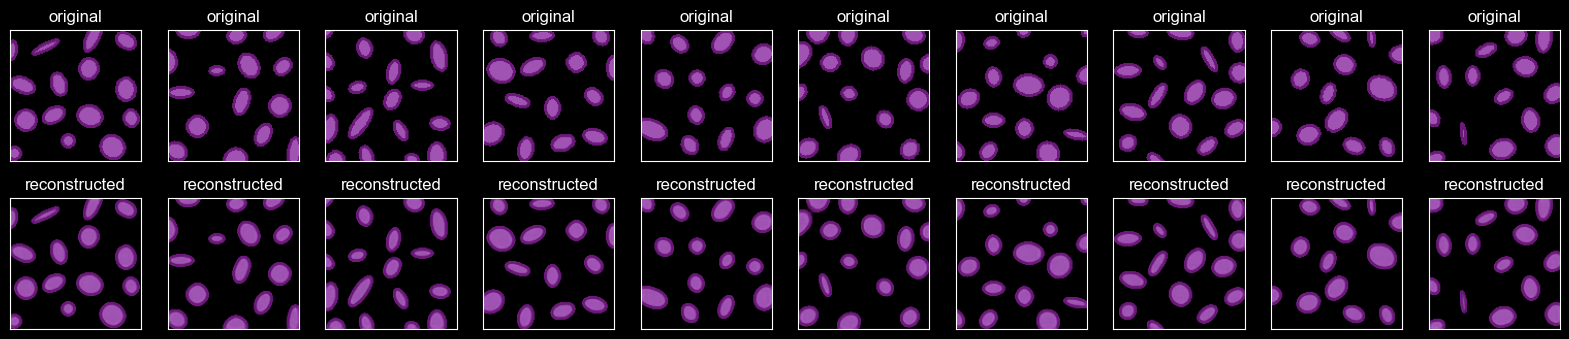

In [49]:
enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    restore_best_weights=True
)

history = enkoder.fit(
    x_traning_data, x_traning_data,
    epochs=50,
    shuffle=True,
    callbacks=[early_stopping],
    validation_data=(x_val_data, x_val_data),
    verbose=1
)

decoded_test = enkoder.predict(x_test_data)
mse_test = enkoder.evaluate(x_test_data, x_test_data, verbose=0)[0]

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")
print(f"MSE Normal: {mse_test:.6f}")

visualize_output(x_test_data, decoded_test, 10)

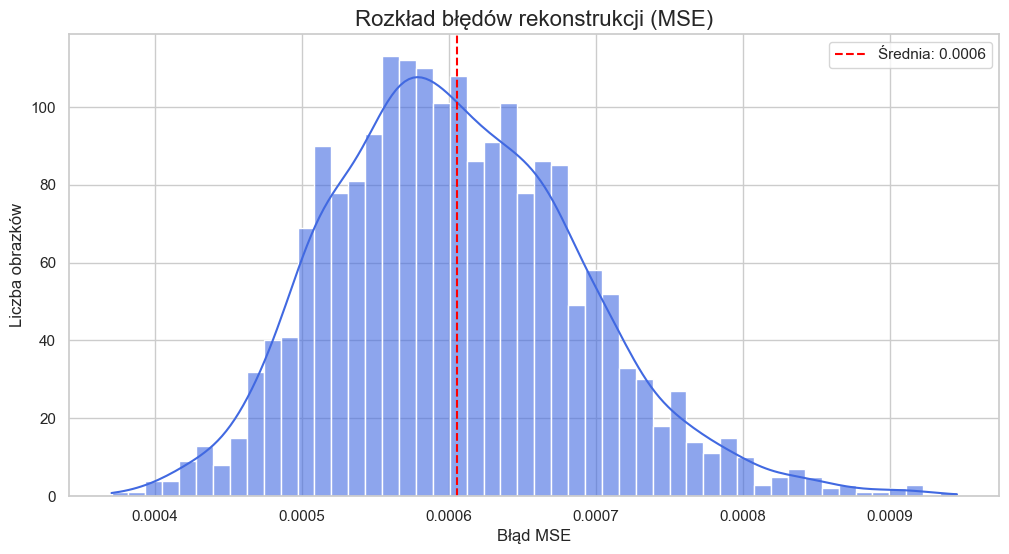

In [62]:
mse_test_per_image = np.mean(np.square(x_test_data - decoded_test), axis=(1, 2, 3))

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.histplot(mse_per_image, bins=50, kde=True, color="royalblue", alpha=0.6)

mean_val = np.mean(mse_per_image)
plt.axvline(mean_val, color='red', linestyle='--', label=f'Średnia: {mean_val:.4f}')

plt.title("Rozkład błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [50]:
test = [{'Eksperyment': 'MSE Test', 'Wynik': mse_test}]

mse_dataset = pd.DataFrame(test, columns=['Eksperyment', 'Wynik'])
mse_dataset

,Eksperyment,Wynik
0,MSE Test,0.149987


Wyniki eksperymentu pierwszego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
MSE Large:  0.334520


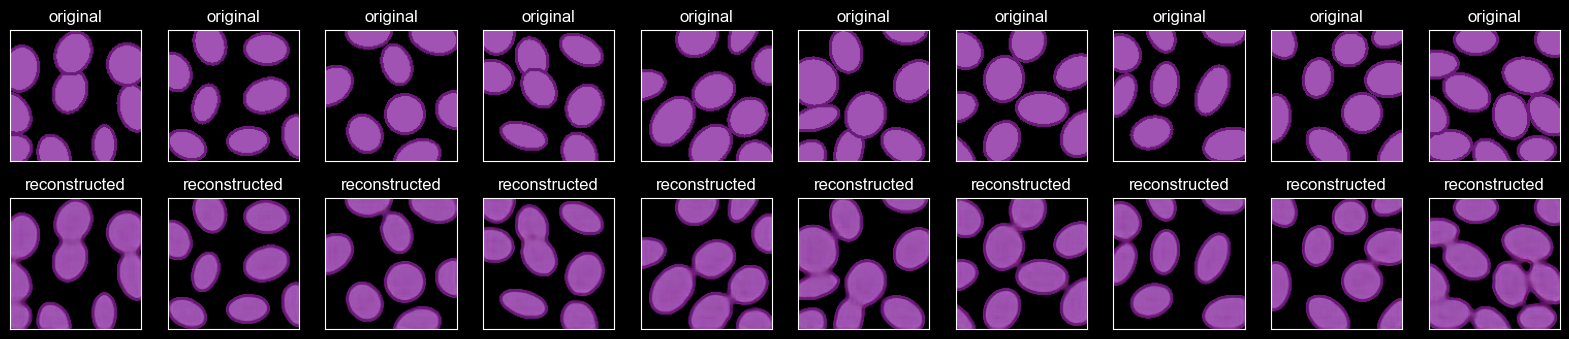

In [51]:
x_large_cells_data = preprocess(larger_cells_set)

decoded_large_cells = enkoder.predict(x_large_cells_data)
mse_large = enkoder.evaluate(x_large_cells_data, x_large_cells_data, verbose=0)[0]

print(f"MSE Large:  {mse_large:.6f}")

visualize_output(x_large_cells_data, decoded_large_cells, 10)

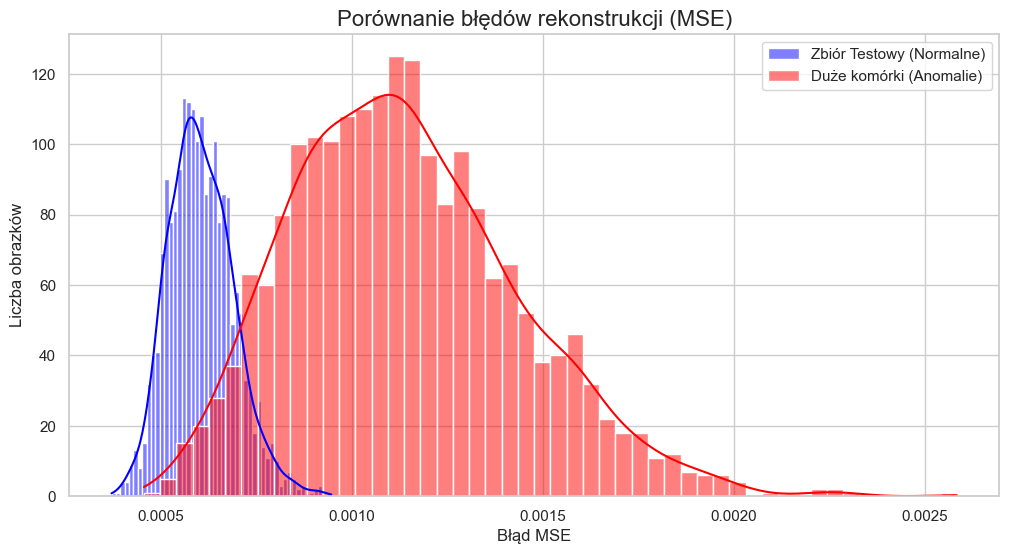

In [63]:
mse_large_per_image = np.mean(np.square(x_large_cells_data - decoded_large_cells), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(mse_large_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Duże komórki (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [52]:
larger_cells = [{'Eksperyment': 'MSE Large', 'Wynik': mse_large}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(larger_cells)],ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE Test,0.149987
1,MSE Large,0.334520


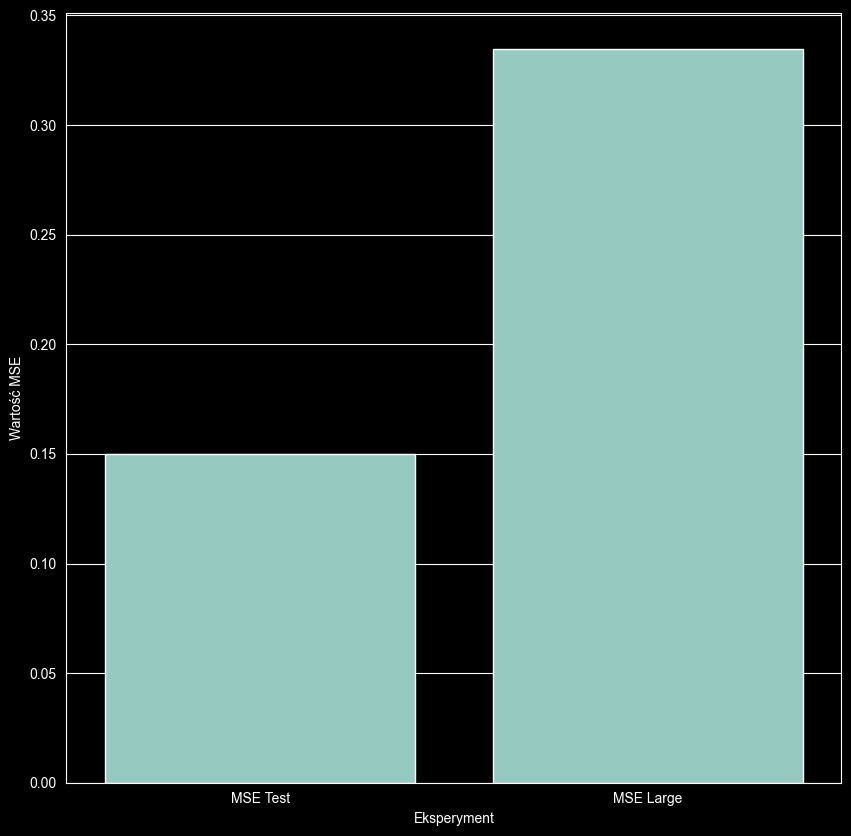

In [53]:
plt.figure(figsize=(10, 10))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

In [57]:
mse_per_image = np.mean(np.square(x_test_data - decoded_test), axis=(1, 2, 3))
mse_per_image


array([0.00070544, 0.00061431, 0.00068504, ..., 0.00053221, 0.000677  ,
       0.00067156], dtype=float32)